# This is a notebook for messing with parameter distributions to get "tight" and "wide" simulations

### Load dependencies

In [1]:
import os
import json
import sympy
import requests

import pyciemss
import pyciemss.visuals.plots as plots
import pyciemss.visuals.vega as vega
import pyciemss.visuals.trajectories as trajectories

from mira.metamodel import *
from mira.modeling.amr.petrinet import AMRPetriNetModel, template_model_to_petrinet_json
from mira.sources.amr.petrinet import template_model_from_amr_json

### Grab a few models

In [2]:
MODEL_PATH = "https://raw.githubusercontent.com/DARPA-ASKEM/simulation-integration/main/data/models/"

model1 = os.path.join(MODEL_PATH, "SEIRD_base_model01_petrinet.json")
model2 = os.path.join(MODEL_PATH, "SEIRHD_base_model01_petrinet.json")
model3 = os.path.join(MODEL_PATH, "LV_sheep_foxes.json")

### Set parameters for sampling

In [2]:
start_time = 0.0
end_time = 100.0
logging_step_size = 10.0
num_samples = 100

## Sample the model

,timepoint_id,sample_id,timepoint_unknown,persistent_beta_param,persistent_death_param,persistent_gamma_param,persistent_I0_param,D_state,E_state,I_state,R_state,S_state,infected_observable_state,dead_observable_state
0,0,0,10.0,0.314078,0.007034,0.240406,6.01508,0.375621,32.783817,29.595821,53.025963,19339974.0,29.595821,0.375621
1,1,0,20.0,0.314078,0.007034,0.240406,6.01508,0.976326,46.420498,42.129662,137.827850,19339814.0,42.129662,0.976326
2,2,0,30.0,0.314078,0.007034,0.240406,6.01508,1.829547,65.905502,59.815071,258.276154,19339654.0,59.815071,1.829547
3,3,0,40.0,0.314078,0.007034,0.240406,6.01508,3.040918,93.568962,84.922607,429.284790,19339432.0,84.922607,3.040918
4,4,0,50.0,0.314078,0.007034,0.240406,6.01508,4.760754,132.841354,120.566849,672.072571,19339114.0,120.566849,4.760754


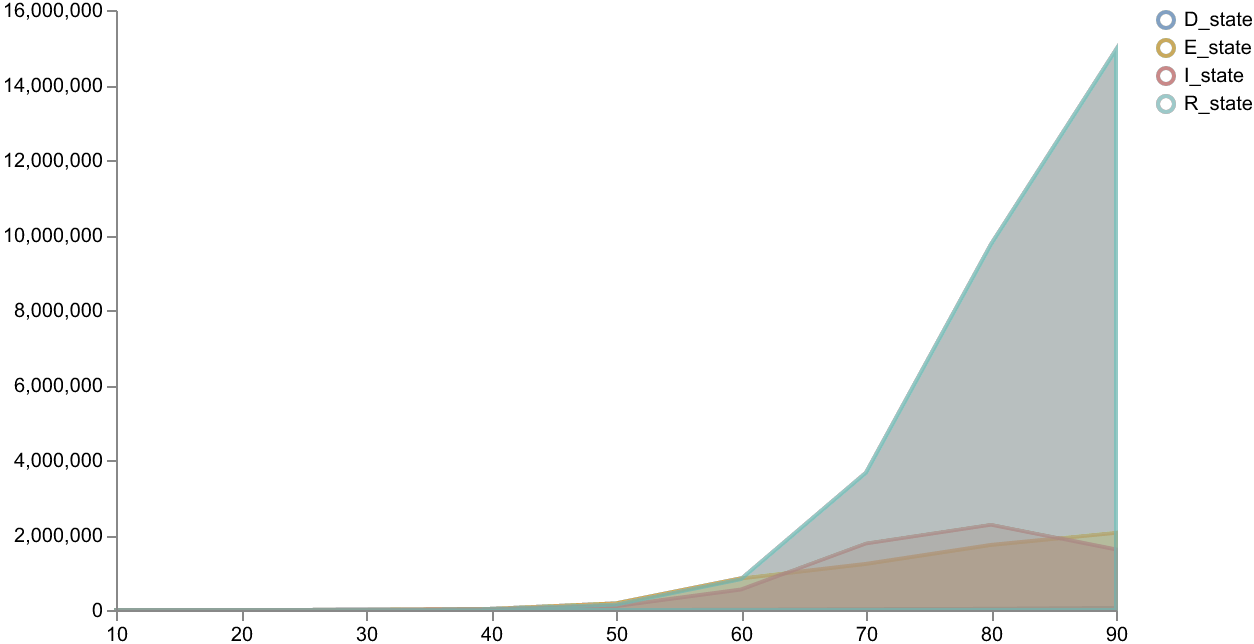

In [4]:
result1 = pyciemss.sample(model1, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

# Plot results for all states
# schema = plots.trajectories(result1["data"], keep=".*_state")
schema = plots.trajectories(result1["data"], keep=["E_state", "I_state", "R_state", "D_state"])
plots.save_schema(schema, "_schema.json")
plots.ipy_display(schema, dpi=150)

## Change parameter values and uncertainty from the AMR

### Load the model as a template model (from the url)

In [5]:
response = requests.get(model1)
tm = template_model_from_amr_json(json.loads(response.text))

# Print parameters
tm.parameters

{'beta': Parameter(name='beta', display_name=None, description=None, identifiers={}, context={}, units=Unit(expression=1/day), value=0.4, distribution=Distribution(type='Uniform1', parameters={'minimum': 0.05, 'maximum': 0.8})),
 'total_population': Parameter(name='total_population', display_name=None, description=None, identifiers={}, context={}, units=Unit(expression=person), value=19340000.0, distribution=None),
 'I0': Parameter(name='I0', display_name=None, description=None, identifiers={}, context={}, units=Unit(expression=person), value=10.0, distribution=Distribution(type='Uniform1', parameters={'minimum': 1.0, 'maximum': 15.0})),
 'delta': Parameter(name='delta', display_name=None, description=None, identifiers={}, context={}, units=Unit(expression=1/day), value=0.25, distribution=None),
 'death': Parameter(name='death', display_name=None, description=None, identifiers={}, context={}, units=Unit(expression=1/day), value=0.007, distribution=Distribution(type='Uniform1', paramete

### Change parameter values and distributions

In [6]:
# Change `beta` parameter value
tm.parameters["beta"].value = 0.2
# Tighten `beta` distribution
tm.parameters["beta"].distribution = Distribution(type='StandardUniform1',
                                                 parameters={'minimum': 0.199, 'maximum': 0.201})

# Change `gamma` parameter value
tm.parameters["gamma"].value = 0.25
# Remove `gamma` distribution
tm.parameters["gamma"].distribution = None

# Remove `I0` distribution
tm.parameters["I0"].distribution = None
# Remove `death` distribution
tm.parameters["death"].distribution = None

# Save as updated AMR
with open('update_parameters_example.json', 'w') as fh:
    json.dump(template_model_to_petrinet_json(tm), fh, indent=1)

### Sample the updated model

,timepoint_id,sample_id,timepoint_unknown,persistent_beta_param,D_state,E_state,I_state,R_state,S_state,infected_observable_state,dead_observable_state
0,0,0,10.0,0.200327,0.357427,18.968304,20.886190,50.703548,19339950.0,20.886190,0.357427
1,1,0,20.0,0.200327,0.680740,14.491301,16.185917,96.567871,19339914.0,16.185917,0.680740
2,2,0,30.0,0.200327,0.929929,11.149060,12.454868,131.917084,19339886.0,12.454868,0.929929
3,3,0,40.0,0.200327,1.121665,8.578341,9.583082,159.116257,19339864.0,9.583082,1.121665
4,4,0,50.0,0.200327,1.269191,6.600378,7.373451,180.043777,19339846.0,7.373451,1.269191


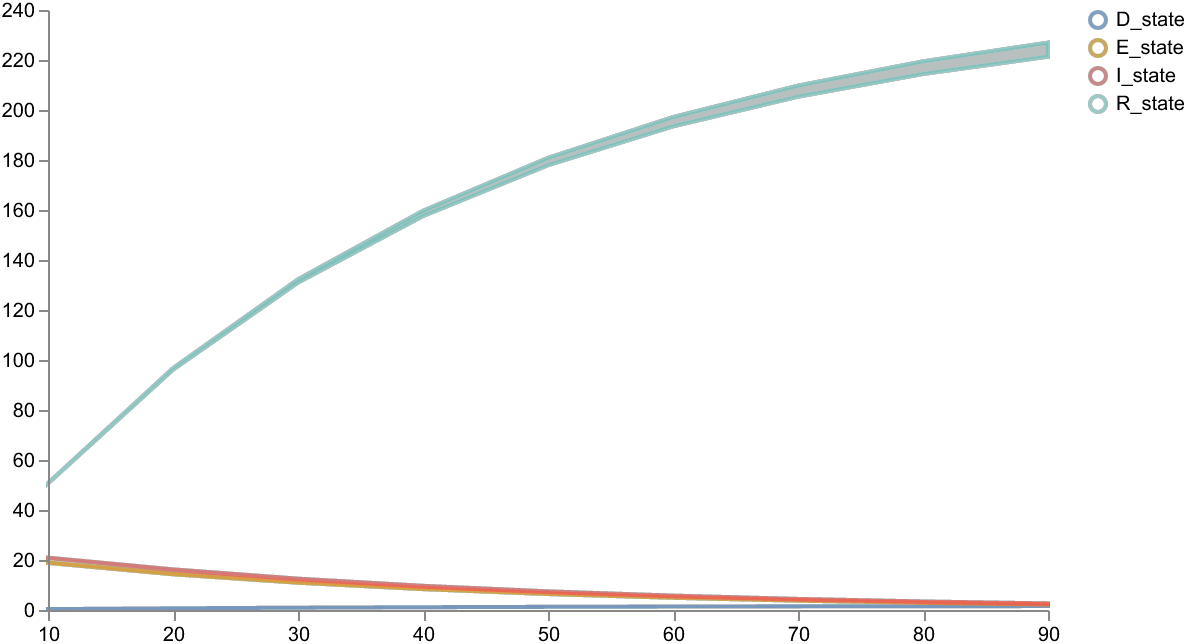

In [3]:
updated_model = "update_parameters_example.json"
result1 = pyciemss.sample(updated_model, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

# Plot results for all states
# schema = plots.trajectories(result1["data"], keep=".*_state")
schema = plots.trajectories(result1["data"], keep=["E_state", "I_state", "R_state", "D_state"])
plots.save_schema(schema, "_schema.json")
plots.ipy_display(schema, dpi=150)

### Change parameters again (from the local model)

In [4]:
filename = updated_model
with open(filename, 'r') as fh:
    tm = template_model_from_amr_json(json.load(fh))

# Change `beta` parameter value
tm.parameters["beta"].value = 0.25

# Change `beta` distribution
tm.parameters["beta"].distribution = Distribution(type='StandardUniform1',
                                                 parameters={'minimum': 0.23, 'maximum': 0.27})

# Save as updated AMR
with open("updated_update_parameters_example.json", "w") as fh:
    json.dump(template_model_to_petrinet_json(tm), fh, indent=1)

### Sample the updated model

,timepoint_id,sample_id,timepoint_unknown,persistent_beta_param,D_state,E_state,I_state,R_state,S_state,infected_observable_state,dead_observable_state
0,0,0,10.0,0.24444,0.382125,24.360712,24.425217,54.207100,19339940.0,24.425217,0.382125
1,1,0,20.0,0.24444,0.805098,23.588255,23.853611,114.208855,19339880.0,23.853611,0.805098
2,2,0,30.0,0.24444,1.216764,22.937059,23.196529,172.606598,19339822.0,23.196529,1.216764
3,3,0,40.0,0.24444,1.617079,22.304430,22.556786,229.394211,19339766.0,22.556786,1.617079
4,4,0,50.0,0.24444,2.006352,21.689129,21.934658,284.615692,19339712.0,21.934658,2.006352


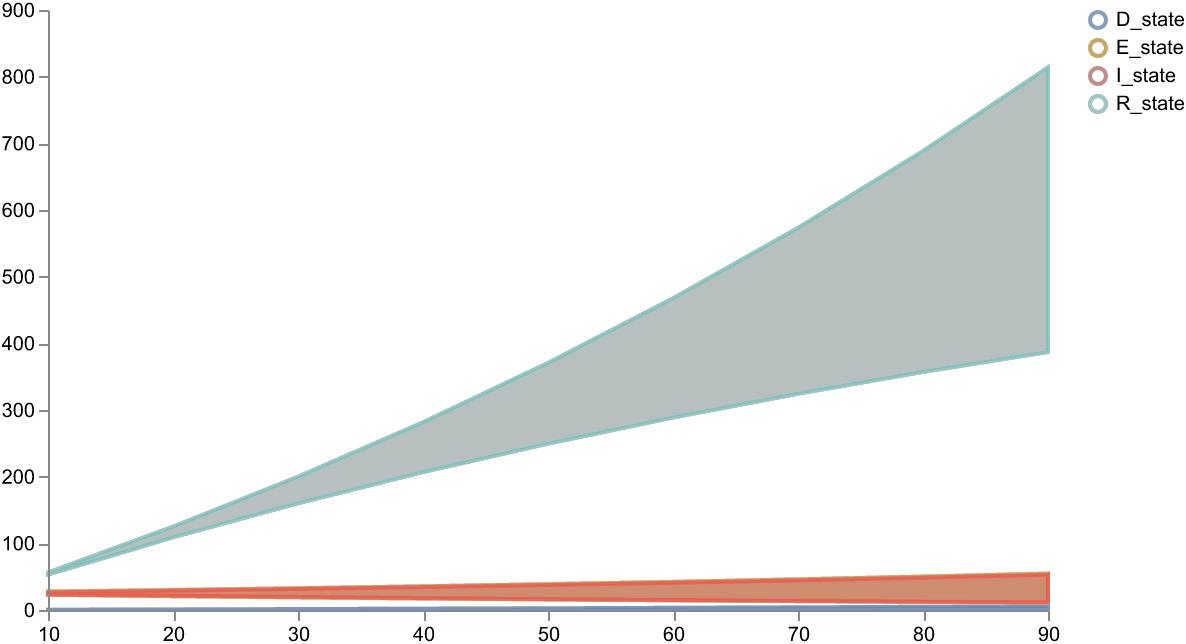

In [5]:
updated_model = "updated_update_parameters_example.json"
result1 = pyciemss.sample(updated_model, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

# Plot results for all states
# schema = plots.trajectories(result1["data"], keep=".*_state")
schema = plots.trajectories(result1["data"], keep=["E_state", "I_state", "R_state", "D_state"])
plots.save_schema(schema, "_schema.json")
plots.ipy_display(schema, dpi=150)